# Tutorial: ACLED Gaza two-week rolling spatial forecasting

This vignette turns ACLED Gaza events into an explicit **rolling 2-week forecasting task**.

For each split, we:

1. Visualize point events in the **last 2 weeks** (training frontier),
2. Visualize points in the **next 2 weeks** (target horizon),
3. Fit a spatial Hawkes model on available history,
4. Forecast the next 2 weeks,
5. Track forecast error split-by-split and inspect paired spatial maps.

We run two spatial assumptions:

- **Agnostic baseline**: isotropic local stencil (no explicit road prior),
- **Road prior**: optional OSM-road-derived `EdgeList` connectivity for Gaza.

In [1]:
import time
NB_START = time.perf_counter()

import json
from datetime import date
from pathlib import Path
from urllib import parse as urlparse
from urllib import request as urlrequest

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.path import Path as MplPath

from motac import (
    CountsTensor,
    EdgeList,
    EventTable,
    GridSpec,
    acled_to_counts,
    fetch_acled_gaza,
    HawkesModelSpec,
    MobilityHawkesModel,
    FitConfig,
    rolling_backtest,
)
from motac.connectivity import make_grid_stencil

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("docs/tutorials/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

In [2]:
devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == "gpu"]

print("Detected devices:", devices)
print("Default backend:", jax.default_backend())
print("JIT remains enabled unless JAX_DISABLE_JIT is set externally.")
if gpu_devices:
    print(f"GPU devices available: {len(gpu_devices)}")
else:
    print("No CUDA-enabled JAX backend detected for this run.")

Detected devices: [CudaDevice(id=0)]
Default backend: gpu
JIT remains enabled unless JAX_DISABLE_JIT is set externally.
GPU devices available: 1


## Optional: refresh an ACLED cache snapshot

This cell is disabled by default. Keep `RUN_NETWORK_FETCH = False` for deterministic local docs runs that rely only on `docs/tutorials/data/acled_events_example.csv`.

In [3]:
RUN_NETWORK_FETCH = False

if RUN_NETWORK_FETCH:
    _ = fetch_acled_gaza(
        start=date(2024, 1, 1),
        end=date(2025, 12, 31),
        region="gaza",
        cache_dir=DATA_DIR,
    )
    print("ACLED cache refreshed under docs/tutorials/data/")
else:
    print("Skipping network fetch; using local ACLED snapshot CSV only.")

Skipping network fetch; using local ACLED snapshot CSV only.


## Load and harmonize ACLED snapshot

We collapse ACLED event types into a compact taxonomy and keep a recent, deterministic local window for tutorial runtime.

In [4]:
snapshot_path = DATA_DIR / "acled_events_example.csv"
if not snapshot_path.exists():
    raise FileNotFoundError(f"Missing snapshot: {snapshot_path}")

GAZA_BOUNDARY_CACHE = DATA_DIR / "gaza_boundary.geojson"
DEFAULT_GAZA_BBOX = (34.2, 34.6, 31.2, 31.6)


def close_ring(coords: np.ndarray) -> np.ndarray:
    arr = np.asarray(coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("Polygon coordinates must have shape [N, 2].")
    if len(arr) < 3:
        raise ValueError("Polygon ring must contain at least 3 coordinates.")
    if not np.allclose(arr[0], arr[-1]):
        arr = np.vstack([arr, arr[0]])
    return arr


def ring_area(coords: np.ndarray) -> float:
    arr = close_ring(coords)
    x = arr[:, 0]
    y = arr[:, 1]
    return 0.5 * abs(np.dot(x[:-1], y[1:]) - np.dot(y[:-1], x[1:]))


def extract_outer_ring(geometry: dict[str, object]) -> np.ndarray:
    geom_type = geometry.get("type")
    coords = geometry.get("coordinates")

    if geom_type == "Polygon":
        if not coords:
            raise ValueError("Polygon geometry contains no coordinates.")
        return close_ring(np.asarray(coords[0], dtype=float))

    if geom_type == "MultiPolygon":
        if not coords:
            raise ValueError("MultiPolygon geometry contains no coordinates.")
        rings = [close_ring(np.asarray(poly[0], dtype=float)) for poly in coords if poly]
        if not rings:
            raise ValueError("MultiPolygon geometry contains no polygon rings.")
        return max(rings, key=ring_area)

    raise ValueError(f"Unsupported boundary geometry type: {geom_type}")


def load_gaza_outline(boundary_path: Path, fallback_bbox: tuple[float, float, float, float]) -> np.ndarray:
    if boundary_path.exists():
        payload = json.loads(boundary_path.read_text())
        features = payload.get("features", [])
        if not features:
            raise ValueError(f"Boundary cache exists but contains no features: {boundary_path}")
        return extract_outer_ring(features[0]["geometry"])

    lon_min, lon_max, lat_min, lat_max = fallback_bbox
    return close_ring(
        np.array(
            [
                [lon_min, lat_min],
                [lon_max, lat_min],
                [lon_max, lat_max],
                [lon_min, lat_max],
            ],
            dtype=float,
        )
    )


gaza_outline_lonlat = load_gaza_outline(GAZA_BOUNDARY_CACHE, DEFAULT_GAZA_BBOX)
gaza_path_lonlat = MplPath(gaza_outline_lonlat)
lon_min_poly = float(gaza_outline_lonlat[:, 0].min())
lon_max_poly = float(gaza_outline_lonlat[:, 0].max())
lat_min_poly = float(gaza_outline_lonlat[:, 1].min())
lat_max_poly = float(gaza_outline_lonlat[:, 1].max())
GAZA_BBOX = (lon_min_poly, lon_max_poly, lat_min_poly, lat_max_poly)


def draw_polygon_outline(ax, polygon_xy: np.ndarray, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    ax.plot(polygon_xy[:, 0], polygon_xy[:, 1], color=color, linewidth=linewidth, alpha=alpha)


def draw_gaza_outline(ax, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    draw_polygon_outline(ax, gaza_outline_lonlat, color=color, linewidth=linewidth, alpha=alpha)


_df_raw = pd.read_csv(snapshot_path, low_memory=False)
required_cols = {"event_date", "latitude", "longitude", "event_type"}
missing = required_cols - set(_df_raw.columns)
if missing:
    raise ValueError(f"ACLED snapshot missing required columns: {sorted(missing)}")

df = _df_raw.copy()
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce").dt.floor("D")
df = df.dropna(subset=["event_date", "latitude", "longitude", "event_type"]).copy()

df = df[
    df["longitude"].between(GAZA_BBOX[0], GAZA_BBOX[1])
    & df["latitude"].between(GAZA_BBOX[2], GAZA_BBOX[3])
].copy()

if not df.empty:
    inside_gaza = gaza_path_lonlat.contains_points(
        df[["longitude", "latitude"]].to_numpy(dtype=float),
        radius=1e-9,
    )
    df = df.loc[inside_gaza].copy()

if df.empty:
    raise ValueError("No ACLED events remain after applying the Gaza polygon filter.")


def collapse_event_type(value: object) -> str:
    text = str(value)
    if text == "Explosions/Remote violence":
        return "Explosion"
    if text == "Battles":
        return "Battle"
    if text in {"Riots", "Protests"}:
        return "Riot/Protest"
    if text == "Violence against civilians":
        return "VAC"
    return "Other"


df["event_type_group"] = df["event_type"].map(collapse_event_type)

window_start = df["event_date"].max() - pd.Timedelta(days=730)
df = df[df["event_date"] >= window_start].copy()

top_marks = df["event_type_group"].value_counts().head(4).index.tolist()
df = df[df["event_type_group"].isin(top_marks)].copy()

MAX_EVENTS = 80_000
if len(df) > MAX_EVENTS:
    df = df.sample(MAX_EVENTS, random_state=2026)

df = df.sort_values("event_date").reset_index(drop=True)

mark_palette = {
    "Explosion": "tab:red",
    "Battle": "tab:orange",
    "Riot/Protest": "tab:blue",
    "VAC": "tab:purple",
    "Other": "tab:gray",
}
mark_marker = {
    "Explosion": "x",
    "Battle": "^",
    "Riot/Protest": "o",
    "VAC": "s",
    "Other": "D",
}

print("Loaded rows (post-filter):", len(df))
print("Gaza boundary cache:", GAZA_BOUNDARY_CACHE if GAZA_BOUNDARY_CACHE.exists() else "fallback bbox only")
print("Gaza polygon bounds:", GAZA_BBOX)
print("Date range:", df["event_date"].min().date(), "->", df["event_date"].max().date())
print("Top grouped marks:", top_marks)
df[["event_date", "latitude", "longitude", "event_type", "event_type_group"]].head(3)

Loaded rows (post-filter): 15561
Gaza boundary cache: data/gaza_boundary.geojson
Gaza polygon bounds: (34.2158979, 34.5673243, 31.2201289, 31.5968541)
Date range: 2023-09-05 -> 2024-12-04
Top grouped marks: ['Explosion', 'Battle', 'Other', 'VAC']


,event_date,latitude,longitude,event_type,event_type_group
0,2023-09-05,31.5045,34.4743,Explosions/Remote violence,Explosion
1,2023-09-10,31.4178,34.3503,Strategic developments,Other
2,2023-09-12,31.5045,34.4743,Strategic developments,Other


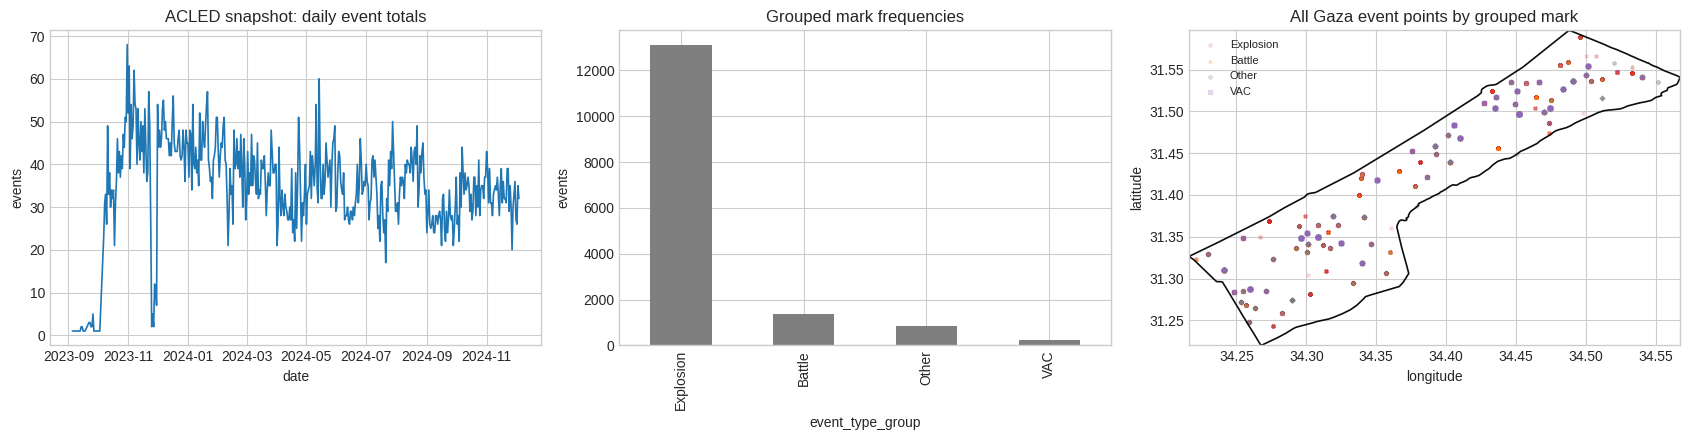

In [5]:
daily_totals = (
    df.groupby("event_date", as_index=False)
      .size()
      .rename(columns={"size": "count"})
)
mark_totals = df["event_type_group"].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(daily_totals["event_date"], daily_totals["count"], linewidth=1.2)
axes[0].set_title("ACLED snapshot: daily event totals")
axes[0].set_xlabel("date")
axes[0].set_ylabel("events")

mark_totals.plot(kind="bar", ax=axes[1], color="tab:gray")
axes[1].set_title("Grouped mark frequencies")
axes[1].set_xlabel("event_type_group")
axes[1].set_ylabel("events")

for mark in top_marks:
    sub = df[df["event_type_group"] == mark]
    axes[2].scatter(
        sub["longitude"],
        sub["latitude"],
        s=5,
        alpha=0.20,
        c=mark_palette.get(mark, "tab:gray"),
        marker=mark_marker.get(mark, "o"),
        label=mark,
    )

draw_gaza_outline(axes[2], linewidth=1.2)
axes[2].set_xlim(GAZA_BBOX[0], GAZA_BBOX[1])
axes[2].set_ylim(GAZA_BBOX[2], GAZA_BBOX[3])
axes[2].set_title("All Gaza event points by grouped mark")
axes[2].set_xlabel("longitude")
axes[2].set_ylabel("latitude")
axes[2].legend(loc="best", fontsize=8)

plt.tight_layout()

## Build a Gaza-shaped 2-week modelling tensor

We discretize time into **2-week bins** (`dt_days=14`) and space into an **approximately 1 km x 1 km** lattice aligned to Gaza's projected footprint.

Because the core `GridSpec` is rectangular, we use the Gaza polygon to define:

- a tight modelling extent,
- the number of rows and columns implied by ~1 km cells,
- a Boolean Gaza mask for plotting and diagnostics.

Then we define the strict rolling task:

- fit on the first 2 weeks, forecast next 2 weeks,
- fit on first 4 weeks, forecast next 2 weeks,
- continue until the end of the series.

This still corresponds to `horizon=1`, `step=1`, `min_train=1` on a 14-day tensor.

In [ ]:
extent = GAZA_BBOX

EARTH_RADIUS_M = 6_371_000.0
center_lon = 0.5 * (GAZA_BBOX[0] + GAZA_BBOX[1])
center_lat = 0.5 * (GAZA_BBOX[2] + GAZA_BBOX[3])
cos_center_lat = np.cos(np.deg2rad(center_lat))


def lonlat_to_local_xy(lon: np.ndarray | float, lat: np.ndarray | float) -> tuple[np.ndarray, np.ndarray]:
    lon_arr = np.asarray(lon, dtype=float)
    lat_arr = np.asarray(lat, dtype=float)
    x = np.deg2rad(lon_arr - center_lon) * EARTH_RADIUS_M * cos_center_lat
    y = np.deg2rad(lat_arr - center_lat) * EARTH_RADIUS_M
    return x, y


def local_xy_to_lonlat(x: np.ndarray | float, y: np.ndarray | float) -> tuple[np.ndarray, np.ndarray]:
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    lon = center_lon + np.rad2deg(x_arr / (EARTH_RADIUS_M * max(cos_center_lat, 1e-8)))
    lat = center_lat + np.rad2deg(y_arr / EARTH_RADIUS_M)
    return lon, lat


gaza_outline_x, gaza_outline_y = lonlat_to_local_xy(gaza_outline_lonlat[:, 0], gaza_outline_lonlat[:, 1])
gaza_outline_xy = np.column_stack([gaza_outline_x, gaza_outline_y])
gaza_path_xy = MplPath(gaza_outline_xy)
x_min = float(gaza_outline_xy[:, 0].min())
x_max = float(gaza_outline_xy[:, 0].max())
y_min = float(gaza_outline_xy[:, 1].min())
y_max = float(gaza_outline_xy[:, 1].max())
projected_extent = (x_min, x_max, y_min, y_max)


def draw_gaza_outline_projected(ax, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    draw_polygon_outline(ax, gaza_outline_xy, color=color, linewidth=linewidth, alpha=alpha)


cell_size_m = 1_000.0
width_m = x_max - x_min
height_m = y_max - y_min
n_cols = max(1, int(np.ceil(width_m / cell_size_m)))
n_rows = max(1, int(np.ceil(height_m / cell_size_m)))

grid = GridSpec(shape=(n_rows, n_cols), extent=projected_extent, crs="LOCAL_GAZA_EQUIRECT_M")
H, W = grid.shape
num_nodes = H * W

x_edges = np.linspace(x_min, x_max, W + 1)
y_edges = np.linspace(y_min, y_max, H + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
grid_xx, grid_yy = np.meshgrid(x_centers, y_centers, indexing="xy")

gaza_mask = gaza_path_xy.contains_points(
    np.column_stack([grid_xx.reshape(-1), grid_yy.reshape(-1)]),
    radius=1e-9,
).reshape(H, W)
gaza_mask_flat = gaza_mask.reshape(-1)

grid_lon, grid_lat = local_xy_to_lonlat(grid_xx, grid_yy)

proj_x, proj_y = lonlat_to_local_xy(
    df["longitude"].to_numpy(dtype=float),
    df["latitude"].to_numpy(dtype=float),
)

df_model = df.rename(columns={"event_type_group": "event_type_model"}).copy()
df_model["x_proj"] = proj_x
df_model["y_proj"] = proj_y

events = EventTable(
    df=df_model,
    time_col="event_date",
    lat_col="y_proj",
    lon_col="x_proj",
    mark_col="event_type_model",
)

counts_base = acled_to_counts(events, grid, marks=top_marks, dt_days=14)
agnostic_connectivity = make_grid_stencil(kind="gaussian", size=3, sigma=1.0)
counts_agnostic = counts_base.with_connectivity(agnostic_connectivity)

preview_splits = counts_agnostic.rolling_origin_splits(horizon=1, step=1, min_train=1)
split_rows = []
for i, split in enumerate(preview_splits):
    test_start = pd.Timestamp(split.test.t0)
    test_end = test_start + pd.Timedelta(days=counts_agnostic.dt_days)
    train_end = test_start
    train_start = train_end - pd.Timedelta(days=counts_agnostic.dt_days)

    split_rows.append(
        {
            "split": i,
            "train_points": int(np.asarray(split.train.y[-1]).sum()),
            "test_points": int(np.asarray(split.test.y[0]).sum()),
            "train_start": train_start,
            "train_end": train_end,
            "test_start": test_start,
            "test_end": test_end,
        }
    )

split_table = pd.DataFrame(split_rows)
num_example_splits = min(3, len(split_table))
plot_split_ids = sorted(set(np.linspace(0, len(split_table) - 1, num=num_example_splits, dtype=int).tolist()))

print("2-week counts tensor shape [T, J, M]:", counts_agnostic.y.shape)
print("Projected grid CRS:", grid.crs)
print("Projected grid shape:", grid.shape)
print("Approximate grid cell size (m):", round(width_m / W, 1), "x", round(height_m / H, 1))
print("Cells inside Gaza mask:", int(gaza_mask.sum()), "/", int(gaza_mask.size))
print("Marks:", counts_agnostic.marks)
print("Total events represented:", float(np.asarray(counts_agnostic.y).sum()))
print("Rolling splits (2-week task):", len(split_table))
print("Representative split ids for plotting:", plot_split_ids)
split_table.head(6)

2-week counts tensor shape [T, J, M]: (33, 1428, 4)
Projected grid CRS: LOCAL_GAZA_EQUIRECT_M
Projected grid shape: (42, 34)
Approximate grid cell size (m): 980.9 x 997.4
Cells inside Gaza mask: 388 / 1428
Marks: ('Explosion', 'Battle', 'Other', 'VAC')
Total events represented: 15561.0
Rolling splits (2-week task): 32
Representative split ids for plotting: [0, 6, 12, 18, 24, 31]


,split,train_points,test_points,train_start,train_end,test_start,test_end
0,0,11,18,2023-09-05,2023-09-19,2023-09-19,2023-10-03
1,1,18,330,2023-09-19,2023-10-03,2023-10-03,2023-10-17
2,2,330,559,2023-10-03,2023-10-17,2023-10-17,2023-10-31
3,3,559,719,2023-10-17,2023-10-31,2023-10-31,2023-11-14
4,4,719,493,2023-10-31,2023-11-14,2023-11-14,2023-11-28
5,5,493,564,2023-11-14,2023-11-28,2023-11-28,2023-12-12


## Visualize selected 2-week rolling splits in point space

To keep the notebook readable, we show a small set of representative rolling splits.

For each selected split, we display:

- **Left panel**: point events from the last 2 weeks (the immediate training frontier),
- **Right panel**: point events from the next 2 weeks (the forecast target).

This still matches the exact data view used by the rolling-origin task.

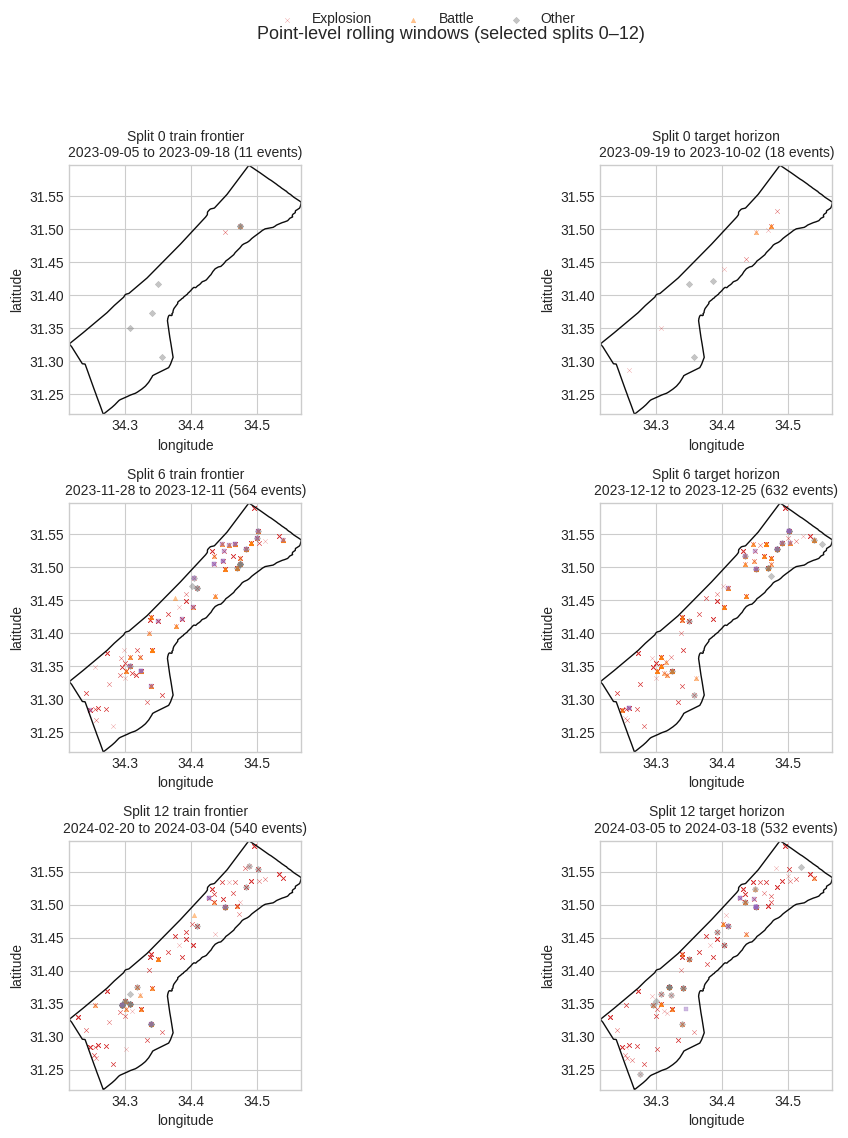

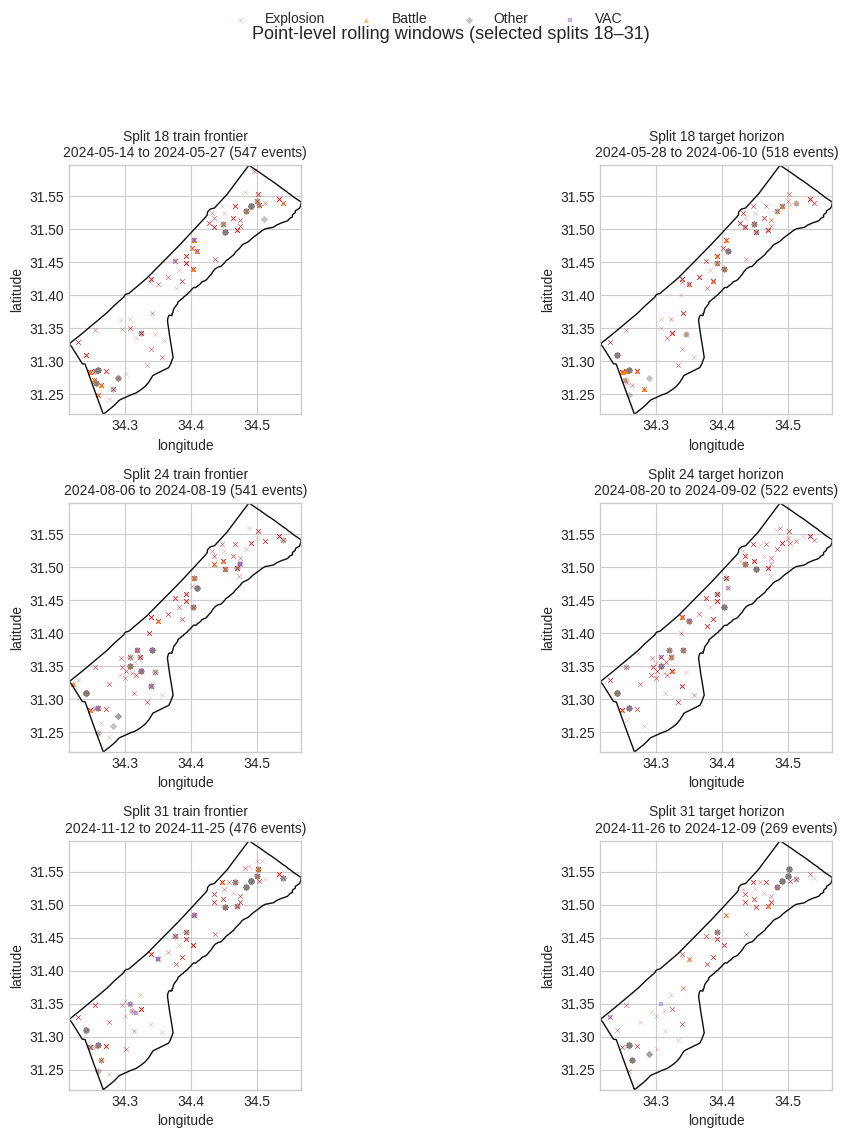

In [7]:
def window_slice_points(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    mask = (df["event_date"] >= start) & (df["event_date"] < end)
    return df.loc[mask].copy()


def plot_marked_points(ax, points_df: pd.DataFrame, title: str) -> None:
    for mark in top_marks:
        sub = points_df[points_df["event_type_group"] == mark]
        if sub.empty:
            continue
        ax.scatter(
            sub["longitude"],
            sub["latitude"],
            s=11,
            alpha=0.45,
            c=mark_palette.get(mark, "tab:gray"),
            marker=mark_marker.get(mark, "o"),
            label=mark,
            linewidths=0.3,
        )

    draw_gaza_outline(ax, linewidth=1.0)

    if points_df.empty:
        ax.text(0.5, 0.5, "No events in window", transform=ax.transAxes, ha="center", va="center")

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title, fontsize=10)


plot_split_table = split_table[split_table["split"].isin(plot_split_ids)].copy().reset_index(drop=True)
SPLITS_PER_FIG = 3
for chunk_start in range(0, len(plot_split_table), SPLITS_PER_FIG):
    chunk = plot_split_table.iloc[chunk_start:chunk_start + SPLITS_PER_FIG]

    fig, axes = plt.subplots(len(chunk), 2, figsize=(12, 3.8 * len(chunk)), squeeze=False)
    for row_i, row in enumerate(chunk.itertuples(index=False)):
        train_points = window_slice_points(pd.Timestamp(row.train_start), pd.Timestamp(row.train_end))
        test_points = window_slice_points(pd.Timestamp(row.test_start), pd.Timestamp(row.test_end))

        plot_marked_points(
            axes[row_i, 0],
            train_points,
            f"Split {int(row.split)} train frontier\n{pd.Timestamp(row.train_start).date()} to {(pd.Timestamp(row.train_end) - pd.Timedelta(days=1)).date()} ({len(train_points)} events)",
        )
        plot_marked_points(
            axes[row_i, 1],
            test_points,
            f"Split {int(row.split)} target horizon\n{pd.Timestamp(row.test_start).date()} to {(pd.Timestamp(row.test_end) - pd.Timedelta(days=1)).date()} ({len(test_points)} events)",
        )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)

    first_split = int(chunk.iloc[0]["split"])
    last_split = int(chunk.iloc[-1]["split"])
    fig.suptitle(f"Point-level rolling windows (selected splits {first_split}–{last_split})", fontsize=13)
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
    plt.show()
    plt.close(fig)

In [8]:
spec = HawkesModelSpec(marks=counts_agnostic.marks, temporal_bases=2, observation="poisson")
model = MobilityHawkesModel(spec)

fit_cfg = FitConfig(map_steps=6, map_ensemble_size=1, map_patience=3)

bt_agnostic = rolling_backtest(
    model,
    counts_agnostic,
    horizon=1,
    step=1,
    min_train=1,
    fit_method="map_ensemble",
    fit_config=fit_cfg,
    forecast_samples=24,
    seed=2026,
)


ROAD_SEGMENTS_CACHE = DATA_DIR / "gaza_osm_roads_segments.csv"
RUN_OSM_ROAD_FETCH = False
ROAD_REQUIRED_COLS = ["lon0", "lat0", "lon1", "lat1", "highway"]


def fetch_osm_roads_segments(extent_bbox: tuple[float, float, float, float]) -> pd.DataFrame:
    lon_min, lon_max, lat_min, lat_max = extent_bbox

    query = f"""
[out:json][timeout:180];
(
  way["highway"]({lat_min},{lon_min},{lat_max},{lon_max});
);
(._;>;);
out body;
"""
    body = urlparse.urlencode({"data": query}).encode("utf-8")
    req = urlrequest.Request(
        "https://overpass-api.de/api/interpreter",
        data=body,
        headers={"User-Agent": "motac-acled-tutorial/1.0"},
    )

    with urlrequest.urlopen(req, timeout=180) as resp:
        payload = json.loads(resp.read().decode("utf-8"))

    elements = payload.get("elements", [])
    nodes: dict[int, tuple[float, float]] = {}
    for el in elements:
        if el.get("type") == "node":
            nodes[int(el["id"])] = (float(el["lon"]), float(el["lat"]))

    rows: list[dict[str, object]] = []
    for el in elements:
        if el.get("type") != "way":
            continue
        node_seq = [int(nid) for nid in el.get("nodes", []) if int(nid) in nodes]
        if len(node_seq) < 2:
            continue

        highway_type = str(el.get("tags", {}).get("highway", "road"))
        for n0, n1 in zip(node_seq[:-1], node_seq[1:]):
            lon0, lat0 = nodes[n0]
            lon1, lat1 = nodes[n1]
            rows.append(
                {
                    "lon0": lon0,
                    "lat0": lat0,
                    "lon1": lon1,
                    "lat1": lat1,
                    "highway": highway_type,
                }
            )

    return pd.DataFrame(rows, columns=ROAD_REQUIRED_COLS)


if ROAD_SEGMENTS_CACHE.exists():
    roads_df = pd.read_csv(ROAD_SEGMENTS_CACHE)
    missing_road_cols = sorted(set(ROAD_REQUIRED_COLS) - set(roads_df.columns))
    if missing_road_cols:
        raise ValueError(f"Road cache missing required columns: {missing_road_cols}")
    roads_df = roads_df[ROAD_REQUIRED_COLS].dropna().copy()
    print(f"Loaded cached Gaza OSM road segments: {len(roads_df)}")
elif RUN_OSM_ROAD_FETCH:
    roads_df = fetch_osm_roads_segments(extent)
    roads_df.to_csv(ROAD_SEGMENTS_CACHE, index=False)
    print(f"Fetched + cached Gaza OSM road segments: {len(roads_df)}")
else:
    roads_df = pd.DataFrame(columns=ROAD_REQUIRED_COLS)
    print(
        "No cached Gaza road segments found and network fetch is disabled. "
        "Road-prior run will be skipped unless cache is provided or RUN_OSM_ROAD_FETCH=True."
    )


highway_weight = {
    "motorway": 3.0,
    "trunk": 2.6,
    "primary": 2.1,
    "secondary": 1.6,
    "tertiary": 1.3,
    "residential": 1.0,
    "unclassified": 0.9,
    "service": 0.7,
}


def projected_to_node(x: float, y: float) -> int:
    rr = int(np.clip(((y - y_min) / max(y_max - y_min, 1e-8)) * H, 0, H - 1))
    cc = int(np.clip(((x - x_min) / max(x_max - x_min, 1e-8)) * W, 0, W - 1))
    return rr * W + cc


def roads_to_edgelist(roads: pd.DataFrame, base_self_mass: float = 0.35) -> EdgeList | None:
    if roads.empty:
        return None

    adj = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    np.fill_diagonal(adj, base_self_mass)

    segment_count = 0
    for row in roads.itertuples(index=False):
        x0_arr, y0_arr = lonlat_to_local_xy(float(row.lon0), float(row.lat0))
        x1_arr, y1_arr = lonlat_to_local_xy(float(row.lon1), float(row.lat1))
        x0 = float(np.asarray(x0_arr))
        y0 = float(np.asarray(y0_arr))
        x1 = float(np.asarray(x1_arr))
        y1 = float(np.asarray(y1_arr))

        a = projected_to_node(x0, y0)
        b = projected_to_node(x1, y1)
        if a == b:
            continue
        if not (gaza_mask_flat[a] and gaza_mask_flat[b]):
            continue

        road_type = str(row.highway)
        road_gain = highway_weight.get(road_type, 1.0)
        seg_length = float(np.hypot(x1 - x0, y1 - y0))
        seg_weight = road_gain / max(seg_length, 1.0)

        adj[a, b] += seg_weight
        adj[b, a] += seg_weight
        segment_count += 1

    if segment_count == 0:
        return None

    row_sum = adj.sum(axis=1, keepdims=True)
    adj = adj / np.clip(row_sum, 1e-8, None)

    src, dst = np.where(adj > 0)
    weights = adj[src, dst].astype(np.float32)

    node_xy = np.stack(np.meshgrid(np.arange(H), np.arange(W), indexing="ij"), axis=-1).reshape(-1, 2)
    dist = np.linalg.norm(node_xy[src] - node_xy[dst], axis=1).astype(np.float32)

    return EdgeList(
        src=jnp.asarray(src, dtype=jnp.int32),
        dst=jnp.asarray(dst, dtype=jnp.int32),
        weight=jnp.asarray(weights, dtype=jnp.float32),
        num_nodes=num_nodes,
        distance=jnp.asarray(dist, dtype=jnp.float32),
        meta={"kind": "osm_road_prior", "source": str(ROAD_SEGMENTS_CACHE)},
    )


road_connectivity = roads_to_edgelist(roads_df)
if road_connectivity is None:
    counts_road = None
    bt_road = None
else:
    counts_road = counts_base.with_connectivity(road_connectivity)
    bt_road = rolling_backtest(
        model,
        counts_road,
        horizon=1,
        step=1,
        min_train=1,
        fit_method="map_ensemble",
        fit_config=fit_cfg,
        forecast_samples=24,
        seed=3031,
    )


print("Agnostic split count:", len(bt_agnostic.splits))
if bt_road is None:
    print("Road-prior split count: skipped")
else:
    print("Road-prior split count:", len(bt_road.splits))


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = a.reshape(-1)
    b = b.reshape(-1)
    finite = np.isfinite(a) & np.isfinite(b)
    if finite.sum() < 2:
        return float("nan")
    a = a[finite]
    b = b[finite]
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


def apply_gaza_mask(arr_2d: np.ndarray) -> np.ndarray:
    masked = np.asarray(arr_2d, dtype=float).copy()
    masked[~gaza_mask] = np.nan
    return masked


def summarize_split_metrics(bt, scenario_name: str) -> pd.DataFrame:
    rows = []
    for i, (split, fc) in enumerate(zip(bt.splits, bt.forecasts)):
        y_true_spatial = np.asarray(split.test.y).sum(axis=(0, 2)).reshape(H, W)
        y_pred_spatial = np.asarray(fc.mean).sum(axis=(0, 2)).reshape(H, W)

        y_true_masked = apply_gaza_mask(y_true_spatial)
        y_pred_masked = apply_gaza_mask(y_pred_spatial)
        err = y_pred_masked - y_true_masked

        y_true_total = float(np.nansum(y_true_masked))
        y_pred_total = float(np.nansum(y_pred_masked))

        test_start = pd.Timestamp(split.test.t0)
        test_end = test_start + pd.Timedelta(days=split.test.dt_days)

        rows.append(
            {
                "scenario": scenario_name,
                "split": i,
                "test_start": test_start,
                "test_end": test_end,
                "true_total": y_true_total,
                "pred_total": y_pred_total,
                "total_abs_error": abs(y_pred_total - y_true_total),
                "spatial_mae": float(np.nanmean(np.abs(err))),
                "spatial_rmse": float(np.sqrt(np.nanmean(err**2))),
                "spatial_corr": safe_corr(y_true_masked, y_pred_masked),
            }
        )

    out = pd.DataFrame(rows)
    out = out.merge(bt.metrics, on="split", how="left")
    return out


diag_agnostic = summarize_split_metrics(bt_agnostic, "agnostic_stencil")
diag_frames = [diag_agnostic]
if bt_road is not None:
    diag_frames.append(summarize_split_metrics(bt_road, "osm_road_prior"))

diag_all = pd.concat(diag_frames, ignore_index=True)

summary = (
    diag_all.groupby("scenario")
    [["log_score", "crps", "coverage_90", "spatial_mae", "spatial_rmse", "spatial_corr", "total_abs_error"]]
    .mean()
    .round(3)
)

print("Mean split-wise metrics by scenario:")
print(summary.to_string())
diag_all.head(8)

Loaded cached Gaza OSM road segments: 207191
Agnostic split count: 32
Road-prior split count: 32
Mean split-wise metrics by scenario:
                  log_score   crps  coverage_90  spatial_mae  spatial_rmse  spatial_corr  total_abs_error
scenario                                                                                                 
agnostic_stencil     -0.180  0.099        0.989        1.725         3.670         0.508           86.263
osm_road_prior       -0.176  0.102        0.986        1.730         3.831         0.425           89.729


,scenario,split,test_start,test_end,true_total,pred_total,total_abs_error,spatial_mae,spatial_rmse,spatial_corr,origin_index,log_score,crps,coverage_90,hotspot_recall
0,agnostic_stencil,0,2023-09-19,2023-10-03,18.0,65.208335,47.208335,0.199850,0.344665,0.255456,0,-0.070050,0.005959,0.997899,0.03
1,agnostic_stencil,1,2023-10-03,2023-10-17,329.0,78.291669,250.708331,0.966602,2.851516,0.254032,1,-0.108656,0.060008,0.988095,0.21
2,agnostic_stencil,2,2023-10-17,2023-10-31,548.0,251.291675,296.708325,1.624248,4.104907,0.549432,2,-0.149234,0.101382,0.988095,0.40
3,agnostic_stencil,3,2023-10-31,2023-11-14,708.0,436.041684,271.958316,2.214454,5.458694,0.481333,3,-0.180199,0.135322,0.987395,0.43
4,agnostic_stencil,4,2023-11-14,2023-11-28,482.0,609.041688,127.041688,1.736791,3.054648,0.583314,4,-0.201852,0.105555,0.988445,0.40
5,agnostic_stencil,5,2023-11-28,2023-12-12,553.0,622.750022,69.750022,1.931057,3.819302,0.520946,5,-0.206473,0.112579,0.986520,0.43
6,agnostic_stencil,6,2023-12-12,2023-12-26,618.0,634.666690,16.666690,2.160009,4.685524,0.553623,6,-0.199328,0.124259,0.987920,0.40
7,agnostic_stencil,7,2023-12-26,2024-01-09,593.0,647.041692,54.041692,2.089454,4.371733,0.487007,7,-0.199247,0.125702,0.987570,0.40


## Compare horizon-wise error and inspect the road prior

The line plots below show how forecast quality changes over successive 2-week horizons.

When a road cache is available, we also visualize the OSM segments used to build the road-prior connectivity.

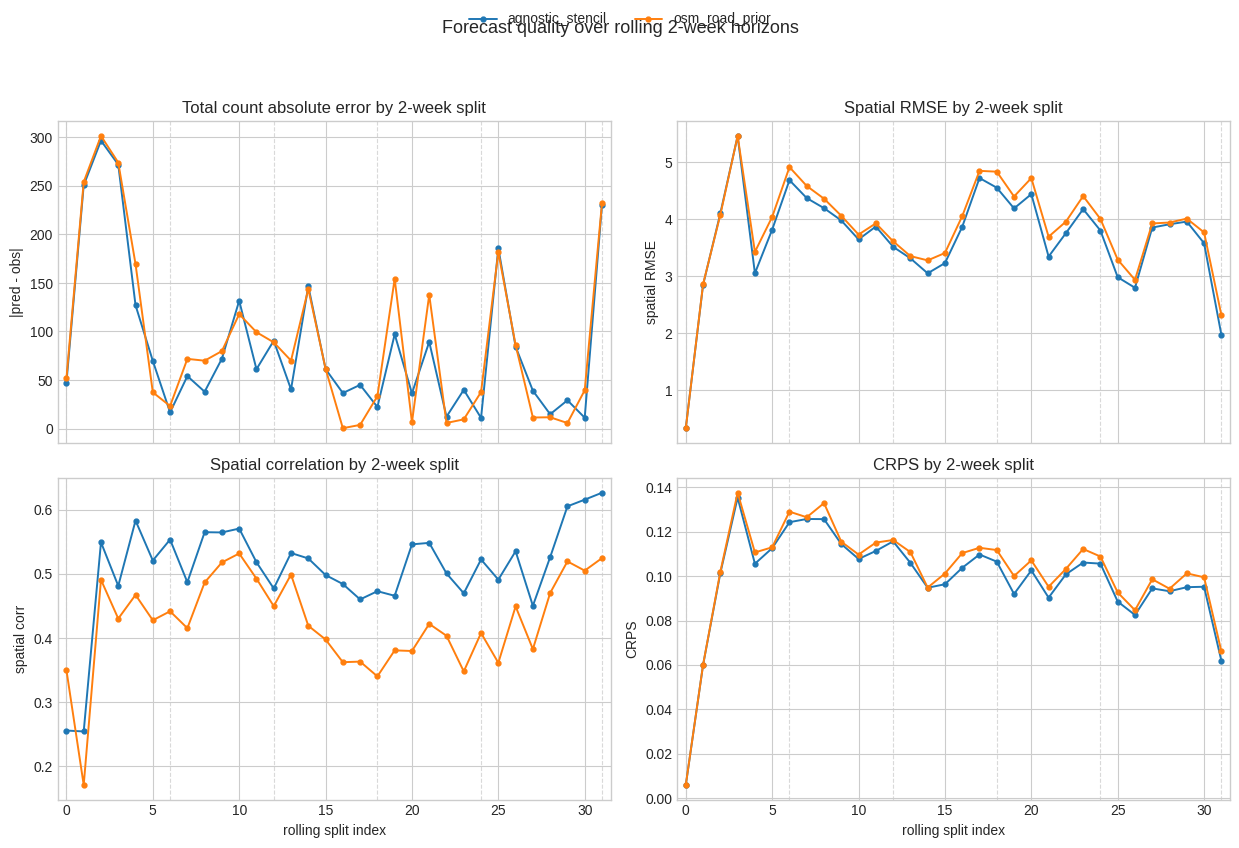

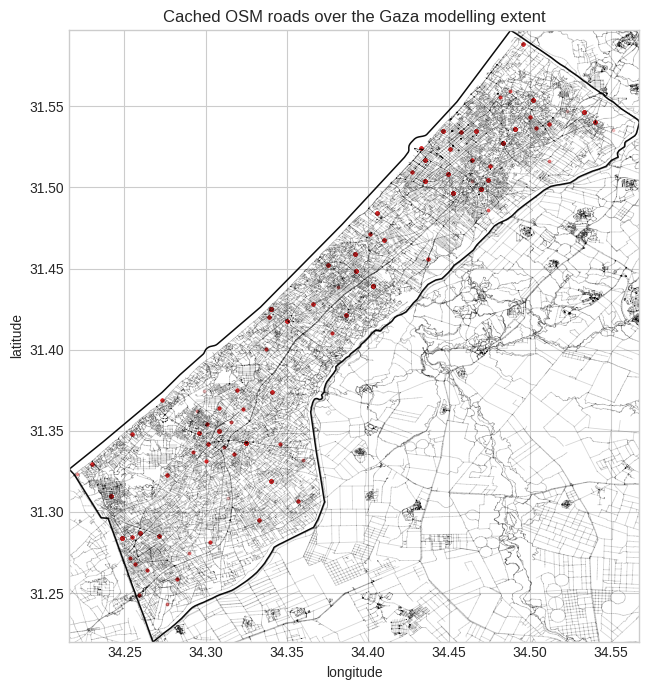

In [9]:
scenario_colors = {
    "agnostic_stencil": "tab:blue",
    "osm_road_prior": "tab:orange",
}

metric_specs = [
    ("total_abs_error", "Total count absolute error by 2-week split", "|pred - obs|"),
    ("spatial_rmse", "Spatial RMSE by 2-week split", "spatial RMSE"),
    ("spatial_corr", "Spatial correlation by 2-week split", "spatial corr"),
    ("crps", "CRPS by 2-week split", "CRPS"),
]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5), sharex=True)
for ax, (metric_key, title, ylabel) in zip(axes.flat, metric_specs):
    for scenario, dsub in diag_all.groupby("scenario"):
        color = scenario_colors.get(scenario, None)
        ax.plot(dsub["split"], dsub[metric_key], marker="o", markersize=3.5, linewidth=1.4, label=scenario, color=color)

    for split_id in plot_split_ids:
        ax.axvline(split_id, color="0.85", linestyle="--", linewidth=0.8, zorder=0)

    ax.set_title(title)
    ax.set_ylabel(ylabel)

axes[1, 0].set_xlabel("rolling split index")
axes[1, 1].set_xlabel("rolling split index")
for ax in axes.flat:
    ax.set_xlim(-0.5, len(split_table) - 0.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
fig.suptitle("Forecast quality over rolling 2-week horizons", fontsize=13)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))
plt.show()
plt.close(fig)

if roads_df.empty:
    print("Road-segment map skipped (no cached/fetched OSM roads available).")
else:
    fig, ax = plt.subplots(figsize=(7, 7))

    for row in roads_df.itertuples(index=False):
        ax.plot([row.lon0, row.lon1], [row.lat0, row.lat1], color="black", alpha=0.16, linewidth=0.6)

    sample_points = df.sample(min(2500, len(df)), random_state=2026)
    ax.scatter(sample_points["longitude"], sample_points["latitude"], s=3, alpha=0.22, color="tab:red")

    draw_gaza_outline(ax, linewidth=1.1)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Cached OSM roads over the Gaza modelling extent")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Paired spatial predictions for representative 2-week horizons

For a small set of representative rolling splits, we compare observed and predicted 2-week spatial totals side-by-side.

We keep a shared colour scale within each scenario so differences across sampled horizons are easier to compare.

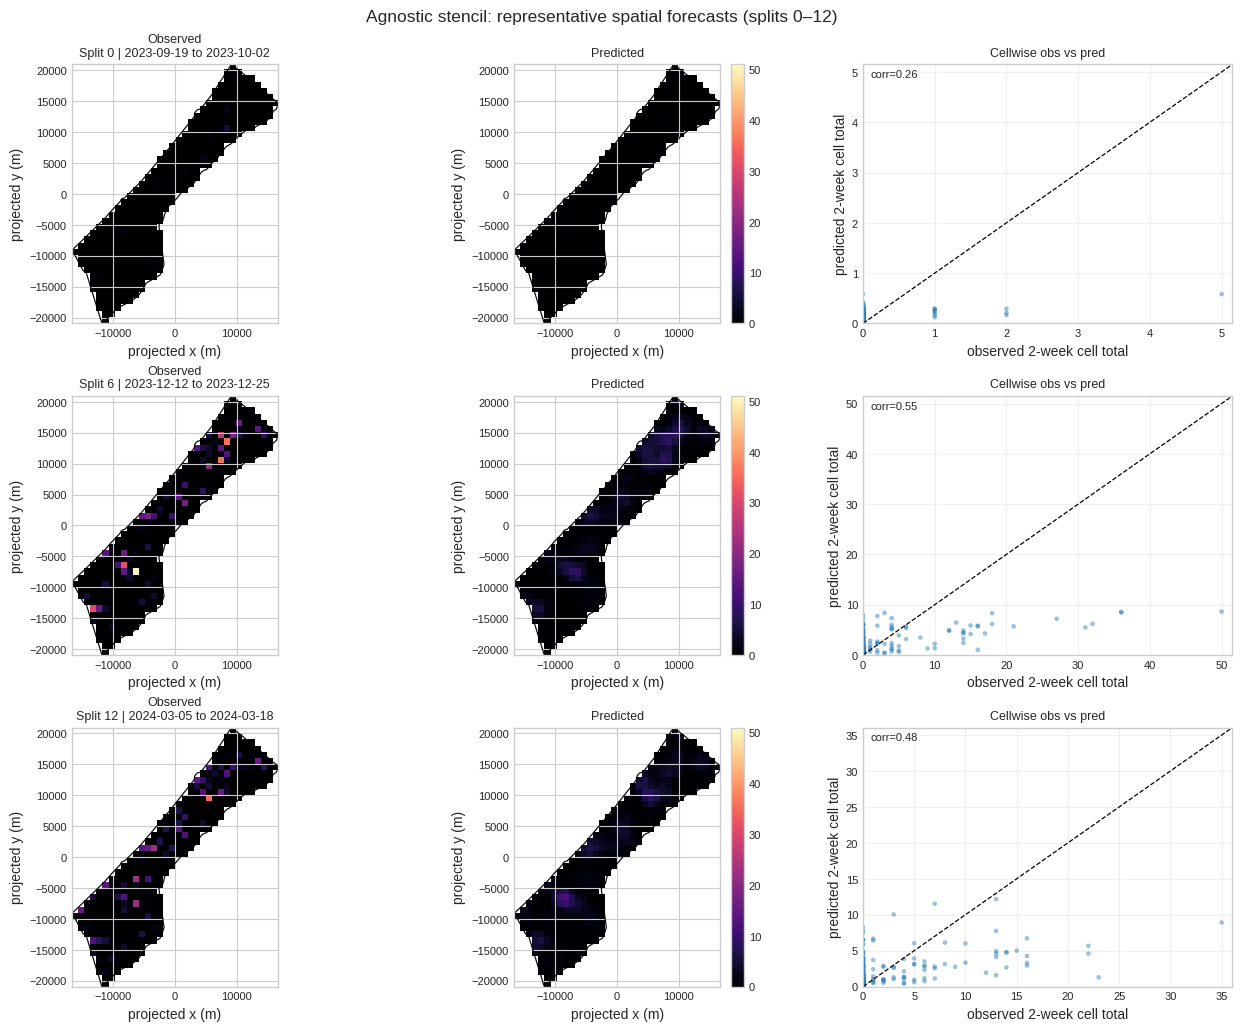

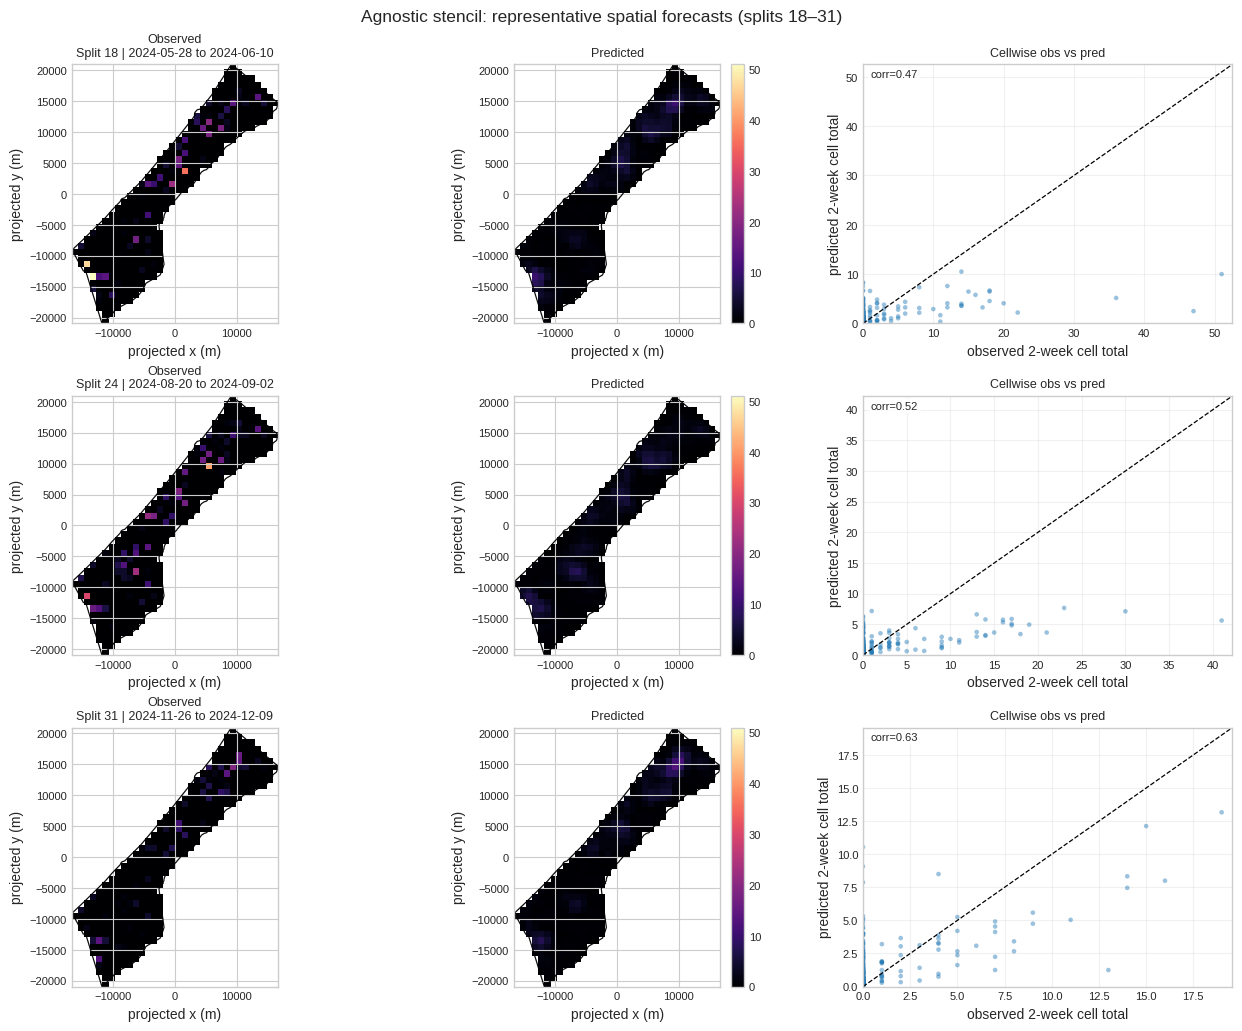

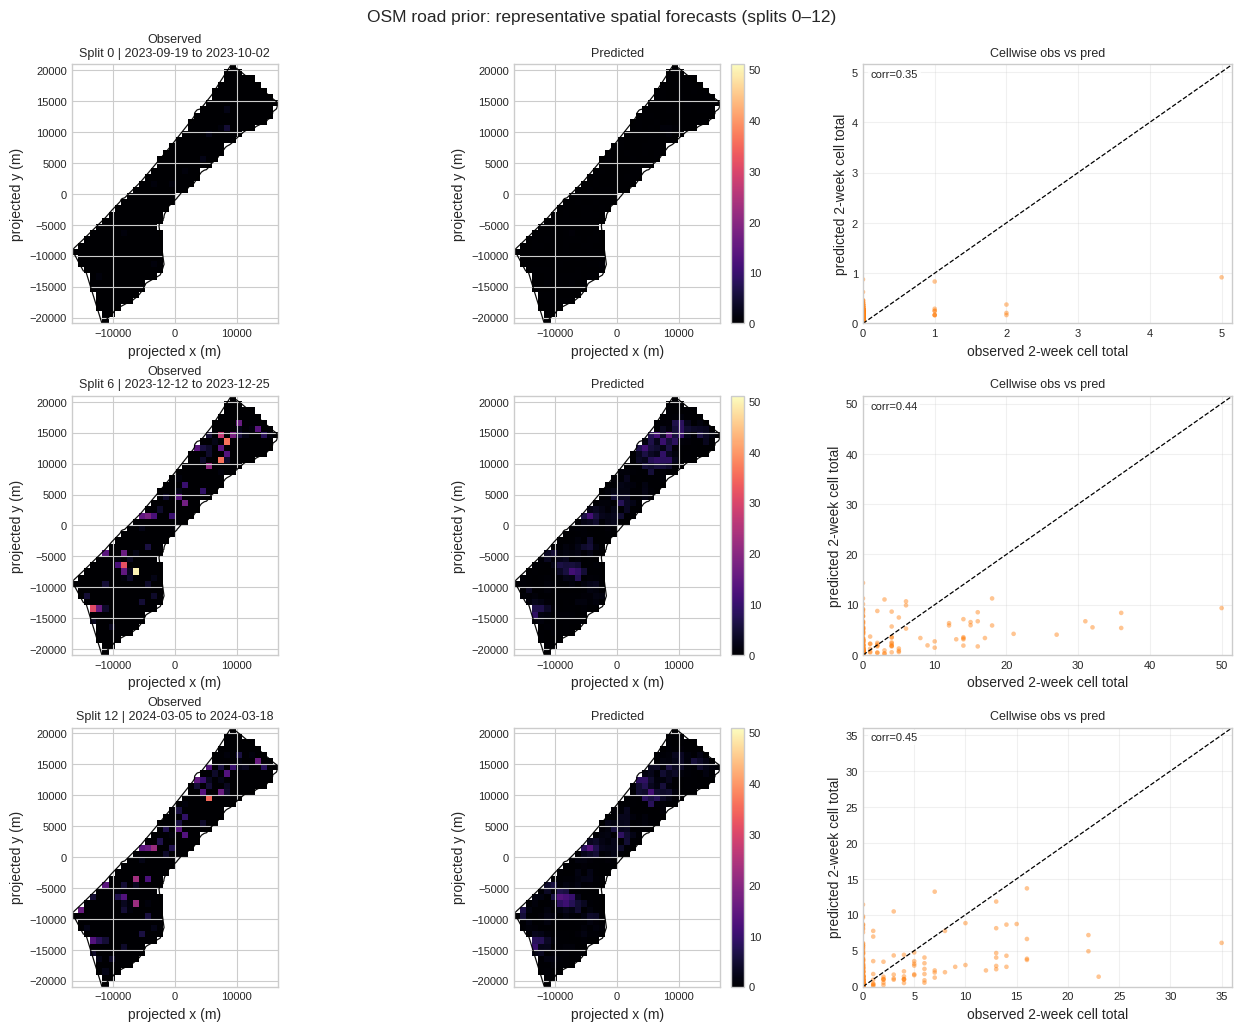

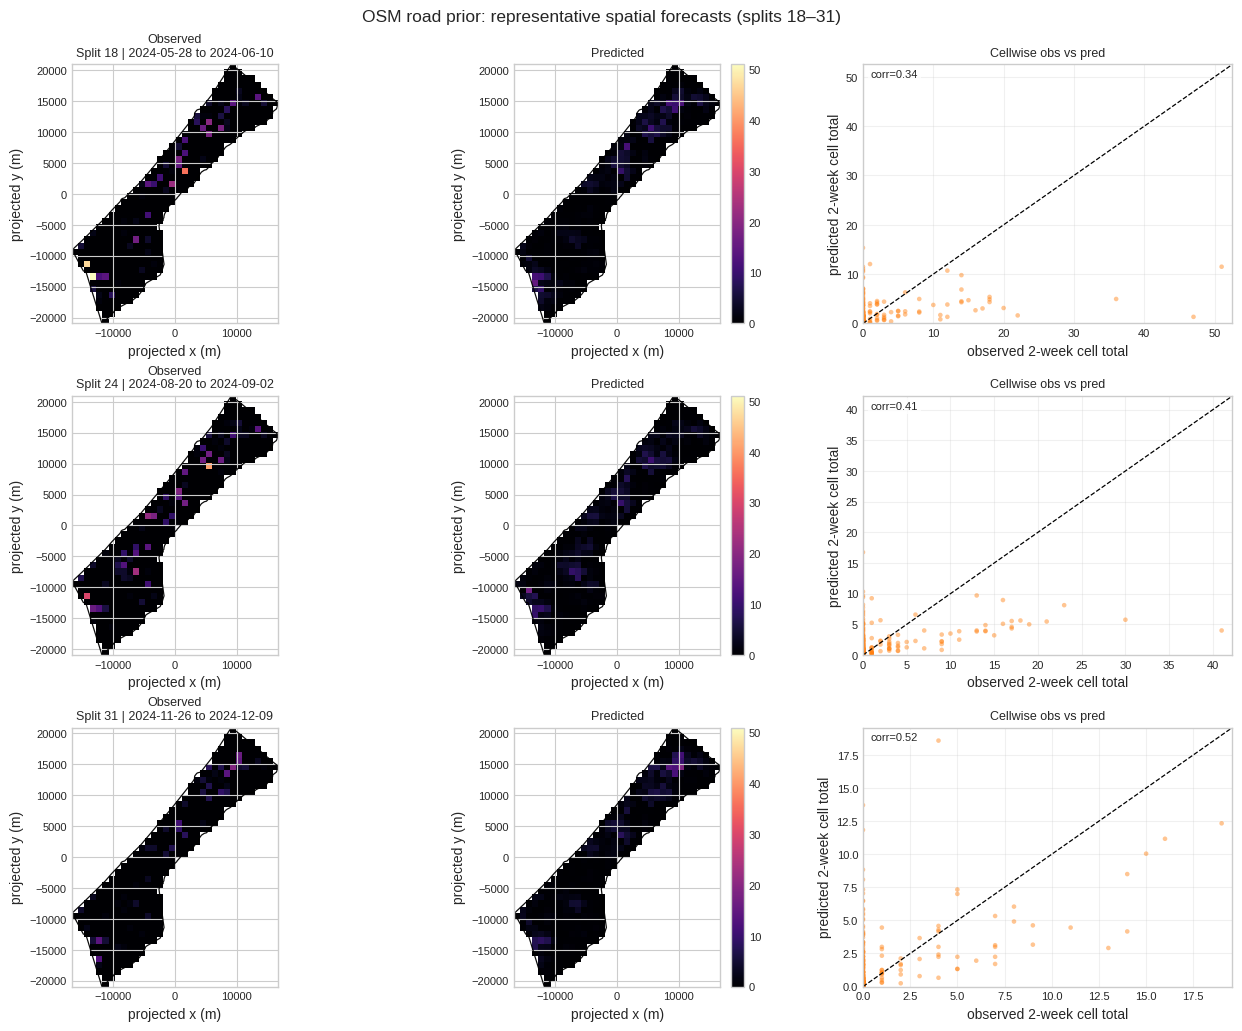

In [14]:
def plot_spatial_pairs(bt, scenario_name: str, selected_splits: list[int] | None = None, rows_per_figure: int = 3) -> None:
    if selected_splits is None:
        selected_splits = list(range(len(bt.splits)))

    selected_splits = [split_id for split_id in selected_splits if 0 <= split_id < len(bt.splits)]
    if not selected_splits:
        print(f"No valid splits selected for {scenario_name}.")
        return

    vmax = max(
        float(
            max(
                np.nanmax(apply_gaza_mask(np.asarray(bt.splits[split_id].test.y).sum(axis=(0, 2)).reshape(H, W))),
                np.nanmax(apply_gaza_mask(np.asarray(bt.forecasts[split_id].mean).sum(axis=(0, 2)).reshape(H, W))),
                1.0,
            )
        )
        for split_id in selected_splits
    )

    for chunk_start in range(0, len(selected_splits), rows_per_figure):
        chunk = selected_splits[chunk_start:chunk_start + rows_per_figure]
        fig = plt.figure(figsize=(13.0, 3.35 * len(chunk) + 0.55))
        gs = fig.add_gridspec(
            len(chunk),
            3,
            width_ratios=[1.0, 1.0, 1.22],
            wspace=0.36,
            hspace=0.28,
        )

        axes = np.empty((len(chunk), 3), dtype=object)
        for r in range(len(chunk)):
            for c in range(3):
                axes[r, c] = fig.add_subplot(gs[r, c])

        for r, split_idx in enumerate(chunk):
            split = bt.splits[split_idx]
            fc = bt.forecasts[split_idx]

            y_true_map = apply_gaza_mask(np.asarray(split.test.y).sum(axis=(0, 2)).reshape(H, W))
            y_pred_map = apply_gaza_mask(np.asarray(fc.mean).sum(axis=(0, 2)).reshape(H, W))

            valid_true = y_true_map[np.isfinite(y_true_map)]
            valid_pred = y_pred_map[np.isfinite(y_pred_map)]
            scatter_max = float(max(np.nanmax(valid_true), np.nanmax(valid_pred), 1.0))
            scatter_lim = scatter_max * 1.03

            im = axes[r, 0].imshow(
                y_true_map,
                cmap="magma",
                vmin=0.0,
                vmax=vmax,
                origin="lower",
                extent=projected_extent,
                aspect="equal",
            )
            axes[r, 1].imshow(
                y_pred_map,
                cmap="magma",
                vmin=0.0,
                vmax=vmax,
                origin="lower",
                extent=projected_extent,
                aspect="equal",
            )

            cbar = fig.colorbar(im, ax=axes[r, 1], fraction=0.05, pad=0.035)
            cbar.ax.tick_params(labelsize=8)

            axes[r, 2].scatter(
                valid_true,
                valid_pred,
                s=11,
                alpha=0.45,
                color="tab:blue" if "agnostic" in scenario_name.lower() else "tab:orange",
                edgecolors="none",
            )
            axes[r, 2].plot([0.0, scatter_lim], [0.0, scatter_lim], linestyle="--", color="black", linewidth=0.9)

            draw_gaza_outline_projected(axes[r, 0], linewidth=0.9)
            draw_gaza_outline_projected(axes[r, 1], linewidth=0.9)

            test_start = pd.Timestamp(split.test.t0)
            test_end = test_start + pd.Timedelta(days=split.test.dt_days) - pd.Timedelta(days=1)
            corr_value = safe_corr(valid_true, valid_pred)
            corr_text = "nan" if np.isnan(corr_value) else f"{corr_value:.2f}"

            axes[r, 0].set_title(
                f"Observed\nSplit {split_idx} | {test_start.date()} to {test_end.date()}",
                fontsize=9,
                pad=6,
            )
            axes[r, 1].set_title("Predicted", fontsize=9, pad=6)
            axes[r, 2].set_title("Cellwise obs vs pred", fontsize=9, pad=6)
            axes[r, 2].text(
                0.02,
                0.98,
                f"corr={corr_text}",
                transform=axes[r, 2].transAxes,
                ha="left",
                va="top",
                fontsize=8,
                bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none", "pad": 2.0},
            )

            for c in range(2):
                axes[r, c].set_xlabel("projected x (m)")
                axes[r, c].set_ylabel("projected y (m)")
                axes[r, c].tick_params(labelsize=8)

            axes[r, 2].set_xlabel("observed 2-week cell total")
            axes[r, 2].set_ylabel("predicted 2-week cell total", labelpad=3)
            axes[r, 2].tick_params(labelsize=8)
            axes[r, 2].set_xlim(0.0, scatter_lim)
            axes[r, 2].set_ylim(0.0, scatter_lim)
            axes[r, 2].grid(alpha=0.28)

        first_split = int(chunk[0])
        last_split = int(chunk[-1])
        fig.suptitle(f"{scenario_name}: representative spatial forecasts (splits {first_split}–{last_split})", fontsize=12.5, y=0.992)
        fig.subplots_adjust(left=0.055, right=0.985, bottom=0.07, top=0.94)
        plt.show()
        plt.close(fig)


plot_spatial_pairs(bt_agnostic, "Agnostic stencil", selected_splits=plot_split_ids)
if bt_road is not None:
    plot_spatial_pairs(bt_road, "OSM road prior", selected_splits=plot_split_ids)
else:
    print("Road-prior spatial map pairs skipped (no OSM road cache/fetch).")

In [11]:
elapsed_sec = time.perf_counter() - NB_START
print(f"Notebook wall-clock runtime: {elapsed_sec:.2f} seconds ({elapsed_sec/60.0:.2f} minutes)")

print("\nKey takeaways:")
print("- The strict 2-week rolling protocol exposes changing difficulty over horizons.")
print("- Point-window plots make each fit/forecast target pair directly interpretable.")
print("- OSM-road prior support is cache-first; provide road cache or enable network fetch to run it.")

Notebook wall-clock runtime: 54.64 seconds (0.91 minutes)

Key takeaways:
- The strict 2-week rolling protocol exposes changing difficulty over horizons.
- Point-window plots make each fit/forecast target pair directly interpretable.
- OSM-road prior support is cache-first; provide road cache or enable network fetch to run it.
